# ISIC 2018 — Skin Lesion Segmentation
## Data Download, Preprocessing & Dataset Preparation

**Project:** Medical Image Segmentation using UNet++  
**Dataset:** ISIC 2018 Challenge — Task 1 (Lesion Segmentation)  
**Purpose:** Download, explore, preprocess, and export clean DataLoaders ready for training.

---
### 📁 Final folder structure after running this notebook:
```
dataset/
  ISIC2018/
    images/       ← RGB .jpg images
    masks/        ← Binary .png masks
```
### ✅ What this notebook does:
1. Install dependencies
2. Download ISIC 2018 dataset (via Kaggle API)
3. Explore & visualize raw data
4. Verify image-mask pairs
5. Analyze mask pixel distribution
6. Define transforms (resize + normalize only, NO augmentation)
7. Build `ISICDataset` class
8. Create train/val DataLoaders
9. Verify output shapes
10. Visualize preprocessed samples
11. Export dataset summary + split info for the training guy

---
## Step 1 — Install Dependencies

In [1]:
!pip install albumentations kaggle Pillow matplotlib tqdm  torchvision -q


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 2 — Download ISIC 2018 Dataset from Kaggle

### 🔑 How to get your Kaggle API key:
1. Go to https://www.kaggle.com → Your Profile → **Settings**
2. Scroll to the **API** section → click **Create New Token**
3. A `kaggle.json` file will download automatically
4. If on **Colab** → uncomment the Colab block below and upload the file when prompted
5. If **running locally** → place `kaggle.json` at `~/.kaggle/kaggle.json`

In [2]:
import os

# ── Google Colab users: uncomment this block ─────────────────────────────────
# from google.colab import files
# uploaded = files.upload()                      # select kaggle.json
# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 0o600)
# print('Kaggle API key configured for Colab.')

# ── Local users ───────────────────────────────────────────────────────────────
# Windows : place kaggle.json at  C:\Users\<YourName>\.kaggle\kaggle.json
# Linux   : place kaggle.json at  ~/.kaggle/kaggle.json

print('Kaggle setup ready — proceed to download.')

Kaggle setup ready — proceed to download.


In [3]:
# Download ISIC 2018 Task 1 Segmentation dataset
# Dataset page: https://www.kaggle.com/datasets/tschandl/isic2018-challenge-task1-data-segmentation

os.makedirs(r'C:\Users\shara\Desktop\AI ML\dl\U-net\dataset\ISIC2018', exist_ok=True)

# !kaggle datasets download \
#     -d tschandl/isic2018-challenge-task1-data-segmentation \
#     -p ../dataset/ISIC2018 \
#     --unzip

print('\n✅ Download complete!')


✅ Download complete!


In [4]:
# Inspect downloaded folder structure
for root, dirs, files in os.walk('../dataset/ISIC2018'):
    level  = root.replace('../dataset/ISIC2018', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        sub = ' ' * 2 * (level + 1)
        for f in files[:4]:
            print(f'{sub}{f}')
        if len(files) > 4:
            print(f'{sub}... and {len(files)-4} more files')

ISIC2018/
  ISIC2018_Task1-2_Test_Input/
    ATTRIBUTION.txt
    ISIC_0012169.jpg
    ISIC_0012236.jpg
    ISIC_0012292.jpg
    ... and 998 more files
  ISIC2018_Task1-2_Training_Input/
    ATTRIBUTION.txt
    ISIC_0000000.jpg
    ISIC_0000001.jpg
    ISIC_0000003.jpg
    ... and 2592 more files
  ISIC2018_Task1-2_Validation_Input/
    ATTRIBUTION.txt
    ISIC_0012255.jpg
    ISIC_0012346.jpg
    ISIC_0012576.jpg
    ... and 98 more files
    .ipynb_checkpoints/
  ISIC2018_Task1_Training_GroundTruth/
    ATTRIBUTION.txt
    ISIC_0000000_segmentation.png
    ISIC_0000001_segmentation.png
    ISIC_0000003_segmentation.png
    ... and 2592 more files


---
## Step 3 — Set Paths & Config

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset

# ── Paths ─────────────────────────────────────────────────────────────────────
# NOTE: Adjust if the unzipped folder names differ on your machine
DATASET_ROOT = '../dataset/ISIC2018'
IMAGES_PATH  = os.path.join(DATASET_ROOT, 'ISIC2018_Task1-2_Training_Input')
MASKS_PATH   = os.path.join(DATASET_ROOT, 'ISIC2018_Task1_Training_GroundTruth')

# ── Config (hand these values to the training guy too) ────────────────────────
IMAGE_SIZE  = 256    # resize to 256x256
BATCH_SIZE  = 8
VAL_SPLIT   = 0.2    # 80% train, 20% val
NUM_WORKERS = 0
RANDOM_SEED = 42

print(f'Images path : {IMAGES_PATH}')
print(f'Masks path  : {MASKS_PATH}')
print(f'Image size  : {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Val split   : {int(VAL_SPLIT*100)}%')

Images path : ../dataset/ISIC2018\ISIC2018_Task1-2_Training_Input
Masks path  : ../dataset/ISIC2018\ISIC2018_Task1_Training_GroundTruth
Image size  : 256x256
Batch size  : 8
Val split   : 20%


---
## Step 4 — Verify Image-Mask Pairs

In [6]:
# Count files
all_images = sorted([f for f in os.listdir(IMAGES_PATH) if f.endswith('.jpg')])
all_masks  = sorted([f for f in os.listdir(MASKS_PATH)  if f.endswith('.png')])

print(f'Total images : {len(all_images)}')
print(f'Total masks  : {len(all_masks)}')
print(f'\nSample image names : {all_images[:3]}')
print(f'Sample mask names  : {all_masks[:3]}')

Total images : 2594
Total masks  : 2594

Sample image names : ['ISIC_0000000.jpg', 'ISIC_0000001.jpg', 'ISIC_0000003.jpg']
Sample mask names  : ['ISIC_0000000_segmentation.png', 'ISIC_0000001_segmentation.png', 'ISIC_0000003_segmentation.png']


In [7]:
# Check every image has a matching mask
# ISIC naming: ISIC_0024306.jpg  <->  ISIC_0024306_segmentation.png

missing = []
for img_file in all_images:
    img_id    = img_file.replace('.jpg', '')
    mask_file = img_id + '_segmentation.png'
    if mask_file not in all_masks:
        missing.append(img_file)

if missing:
    print(f'\u26a0\ufe0f  {len(missing)} images have no matching mask:')
    for m in missing:
        print(f'   {m}')
else:
    print(f'\u2705 All {len(all_images)} images have a matching mask!')

✅ All 2594 images have a matching mask!


In [8]:
# Spot-check image sizes (they vary — we will resize in preprocessing)
sizes = set()
modes = set()
print('Sampling 50 images to check dimensions...')
for img_file in tqdm(all_images[:50]):
    img = Image.open(os.path.join(IMAGES_PATH, img_file))
    sizes.add(img.size)
    modes.add(img.mode)

print(f'\nUnique image sizes  : {sizes}')
print(f'Image channel mode  : {modes}  (should be RGB)')
print('\nSizes vary — all will be resized to 256x256 during preprocessing.')

Sampling 50 images to check dimensions...


100%|██████████| 50/50 [00:00<00:00, 2169.64it/s]


Unique image sizes  : {(1503, 1129), (1022, 767), (1504, 1129)}
Image channel mode  : {'RGB'}  (should be RGB)

Sizes vary — all will be resized to 256x256 during preprocessing.


---
## Step 5 — Visualize Raw Samples

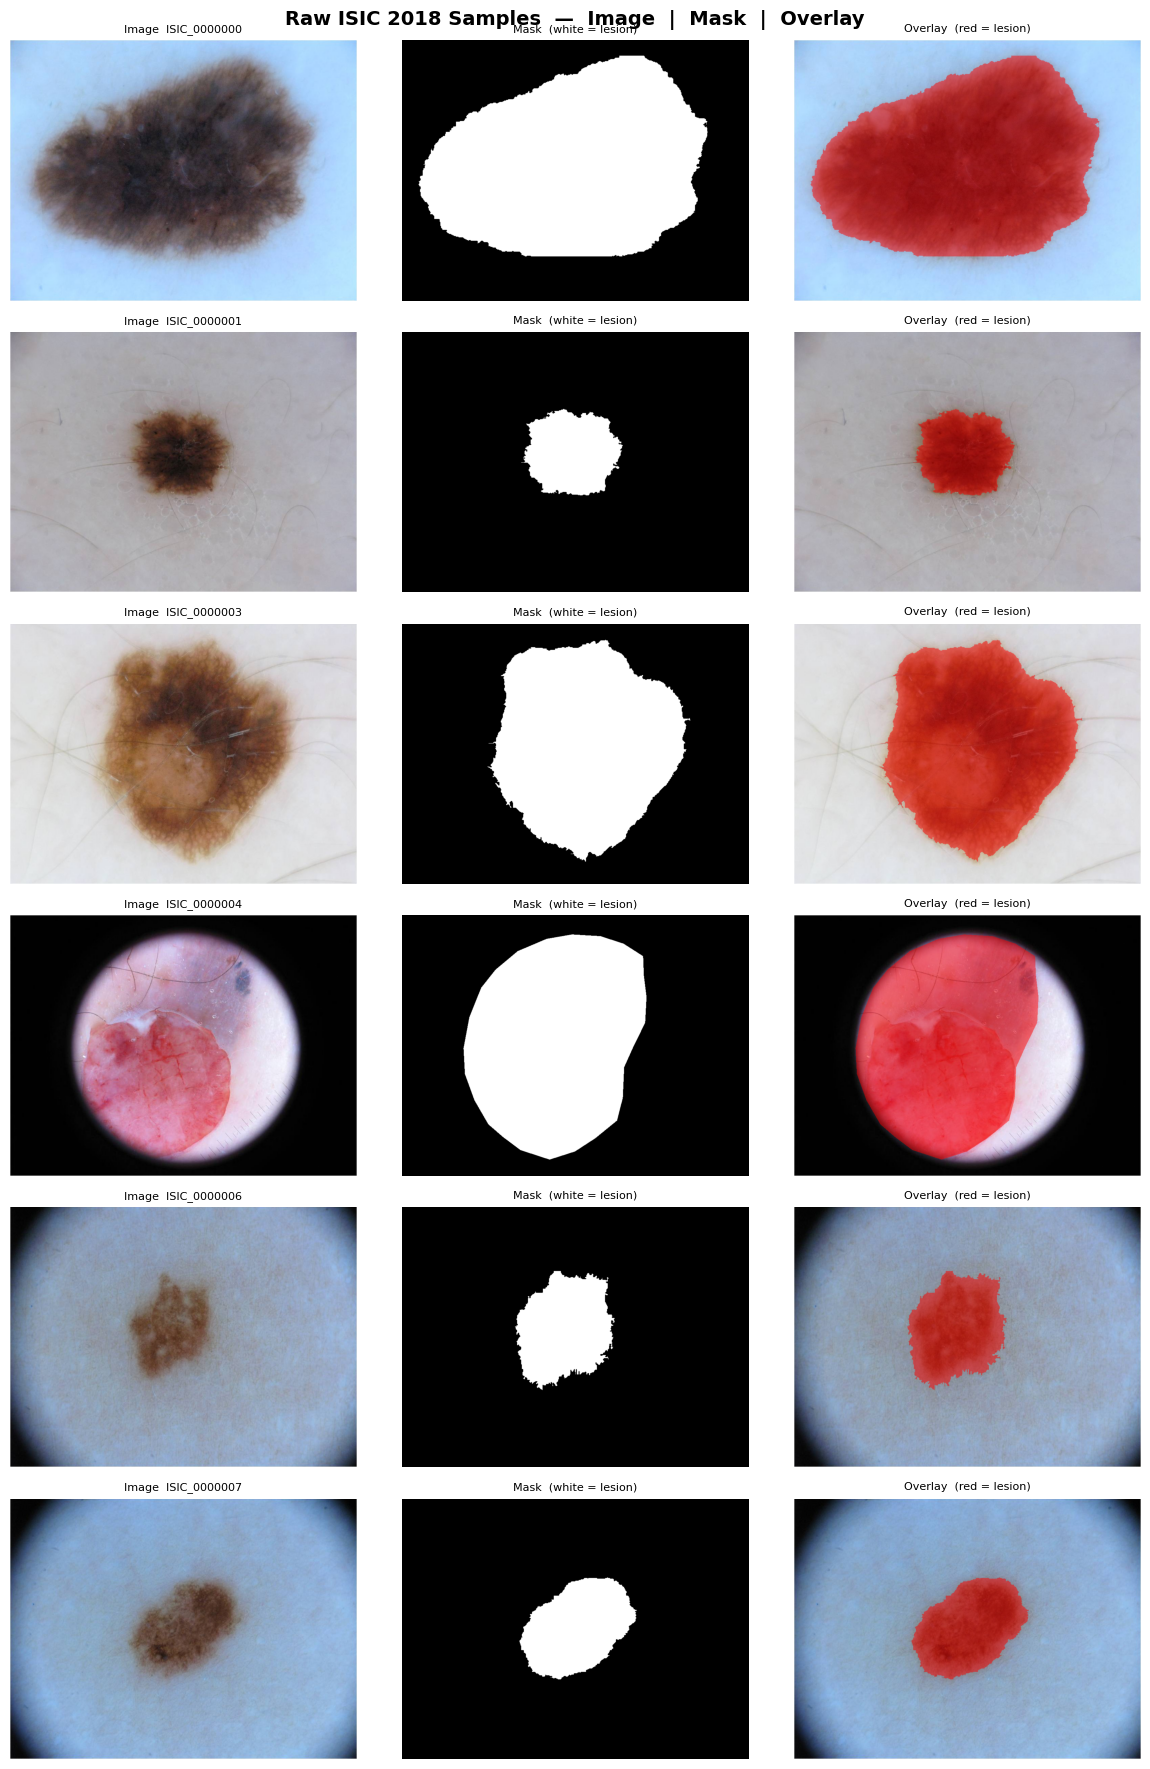

Saved → raw_samples.png


In [9]:
# Show 6 image + mask + overlay samples from raw data
n = 6
fig, axes = plt.subplots(n, 3, figsize=(12, n * 3))
fig.suptitle('Raw ISIC 2018 Samples  —  Image  |  Mask  |  Overlay', fontsize=14, fontweight='bold')

for i, img_file in enumerate(all_images[:n]):
    img_id    = img_file.replace('.jpg', '')
    mask_file = img_id + '_segmentation.png'

    image = np.array(Image.open(os.path.join(IMAGES_PATH, img_file)).convert('RGB'))
    mask  = np.array(Image.open(os.path.join(MASKS_PATH,  mask_file)).convert('L'))

    overlay        = image.copy()
    lesion_pixels  = mask > 127
    overlay[lesion_pixels] = (
        overlay[lesion_pixels] * 0.5 + np.array([255, 0, 0]) * 0.5
    ).astype(np.uint8)

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f'Image  {img_id}', fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title('Mask  (white = lesion)', fontsize=8)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title('Overlay  (red = lesion)', fontsize=8)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('../output/raw_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved \u2192 raw_samples.png')

---
## Step 6 — Analyze Mask Pixel Distribution
Tells us the class balance: how much of each image is lesion vs background.

Analyzing all masks...


100%|██████████| 2594/2594 [01:47<00:00, 24.14it/s] 



📊 Mask Statistics:
   Mean lesion area : 21.4% of image
   Min lesion area  : 0.3%
   Max lesion area  : 98.7%
   Std dev          : 20.8%


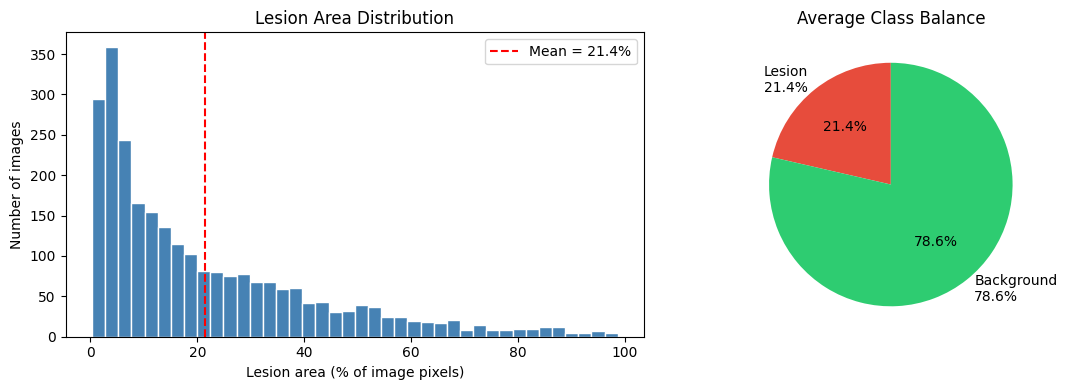

Saved → mask_distribution.png


In [10]:
foreground_ratios = []

print('Analyzing all masks...')
for img_file in tqdm(all_images):
    img_id    = img_file.replace('.jpg', '')
    mask_file = img_id + '_segmentation.png'
    mask      = np.array(Image.open(os.path.join(MASKS_PATH, mask_file)).convert('L'))
    binary    = (mask > 127).astype(np.float32)
    foreground_ratios.append(binary.mean())

foreground_ratios = np.array(foreground_ratios)

print(f'\n\U0001f4ca Mask Statistics:')
print(f'   Mean lesion area : {foreground_ratios.mean()*100:.1f}% of image')
print(f'   Min lesion area  : {foreground_ratios.min()*100:.1f}%')
print(f'   Max lesion area  : {foreground_ratios.max()*100:.1f}%')
print(f'   Std dev          : {foreground_ratios.std()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(foreground_ratios * 100, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(foreground_ratios.mean() * 100, color='red', linestyle='--',
                label=f'Mean = {foreground_ratios.mean()*100:.1f}%')
axes[0].set_xlabel('Lesion area (% of image pixels)')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Lesion Area Distribution')
axes[0].legend()

mean_fg  = foreground_ratios.mean() * 100
mean_bg  = 100 - mean_fg
axes[1].pie([mean_fg, mean_bg],
            labels=[f'Lesion\n{mean_fg:.1f}%', f'Background\n{mean_bg:.1f}%'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Average Class Balance')

plt.tight_layout()
plt.savefig('../output/mask_distribution.png', dpi=100)
plt.show()
print('Saved \u2192 mask_distribution.png')

---
## Step 7 — Define Transforms
**No augmentation** — only Resize → Normalize → ToTensor

In [12]:
# ImageNet mean/std — standard normalization for RGB medical images
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Train transform — resize + normalize only
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# Val transform — identical (NEVER augment validation data)
val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print('\u2705 Transforms defined (NO augmentation):')
print(f'   Train : Resize({IMAGE_SIZE}x{IMAGE_SIZE}) \u2192 Normalize(ImageNet) \u2192 ToTensor')
print(f'   Val   : Resize({IMAGE_SIZE}x{IMAGE_SIZE}) \u2192 Normalize(ImageNet) \u2192 ToTensor')

✅ Transforms defined (NO augmentation):
   Train : Resize(256x256) → Normalize(ImageNet) → ToTensor
   Val   : Resize(256x256) → Normalize(ImageNet) → ToTensor


---
## Step 8 — ISICDataset Class

In [13]:
class ISICDataset(Dataset):
    """
    ISIC 2018 Task 1 — Skin Lesion Segmentation Dataset.

    Expected folder structure:
        images_path/   ISIC_0024306.jpg
        masks_path/    ISIC_0024306_segmentation.png

    Returns:
        image : torch.Tensor  shape (3, H, W)  float32  normalized
        mask  : torch.Tensor  shape (1, H, W)  float32  binary {0.0, 1.0}
    """

    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path  = masks_path
        self.transform   = transform

        # Only keep images that have a corresponding mask
        self.images = []
        for f in sorted(os.listdir(images_path)):
            if not f.endswith('.jpg'):
                continue
            mask_file = f.replace('.jpg', '_segmentation.png')
            if os.path.exists(os.path.join(masks_path, mask_file)):
                self.images.append(f)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_file  = self.images[idx]
        mask_file = img_file.replace('.jpg', '_segmentation.png')

        # Load RGB image
        image = np.array(
            Image.open(os.path.join(self.images_path, img_file)).convert('RGB')
        )

        # Load mask → binarize
        # ISIC masks: 255 = lesion, 0 = background
        mask = np.array(
            Image.open(os.path.join(self.masks_path, mask_file)).convert('L')
        )
        mask = (mask > 127).astype('float32')   # binary {0.0, 1.0}

        # Apply transforms
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']                       # (3, H, W)
            mask  = aug['mask'].float().unsqueeze(0)   # (1, H, W)

        return image, mask


print('\u2705 ISICDataset class defined.')

✅ ISICDataset class defined.


---
## Step 9 — Train / Val Split & DataLoaders

In [14]:
# Build full dataset (no transform yet — just for counting)
full_dataset = ISICDataset(IMAGES_PATH, MASKS_PATH, transform=None)
print(f'Total valid samples : {len(full_dataset)}')

# Reproducible split
torch.manual_seed(RANDOM_SEED)
val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

all_indices       = list(range(len(full_dataset)))
train_idx, val_idx = random_split(all_indices, [train_size, val_size])
train_idx = list(train_idx)
val_idx   = list(val_idx)

print(f'Train samples : {train_size}')
print(f'Val samples   : {val_size}')

Total valid samples : 2594
Train samples : 2076
Val samples   : 518


In [15]:
# Apply transforms to each split
train_ds = Subset(ISICDataset(IMAGES_PATH, MASKS_PATH, transform=train_transform), train_idx)
val_ds   = Subset(ISICDataset(IMAGES_PATH, MASKS_PATH, transform=val_transform),   val_idx)

# Build DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print('✅ DataLoaders created.')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')

✅ DataLoaders created.
   Train batches : 260
   Val batches   : 65


---
## Step 10 — Verify Output Shapes
Confirm that tensors match exactly what UNet++ expects.

In [16]:
images, masks = next(iter(train_loader))

print('=' * 50)
print('   Batch shape verification')
print('=' * 50)
print(f'  images : {images.shape}  dtype={images.dtype}')
print(f'  masks  : {masks.shape}   dtype={masks.dtype}')
print(f'  image  min={images.min():.3f}  max={images.max():.3f}')
print(f'  mask   unique values : {masks.unique().tolist()}')
print('=' * 50)

assert images.shape == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE), '\u274c Image shape mismatch!'
assert masks.shape  == (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE), '\u274c Mask shape mismatch!'
assert set(masks.unique().tolist()).issubset({0.0, 1.0}),       '\u274c Mask is not binary!'

print('\n\u2705 All shape checks passed!')
print('   UNet++ : in=(B,3,256,256)  out=(B,1,256,256)')
print('   Loss   : BCEWithLogitsLoss')

   Batch shape verification
  images : torch.Size([8, 3, 256, 256])  dtype=torch.float32
  masks  : torch.Size([8, 1, 256, 256])   dtype=torch.float32
  image  min=-2.118  max=2.640
  mask   unique values : [0.0, 1.0]

✅ All shape checks passed!
   UNet++ : in=(B,3,256,256)  out=(B,1,256,256)
   Loss   : BCEWithLogitsLoss


---
## Step 11 — Visualize Preprocessed Samples

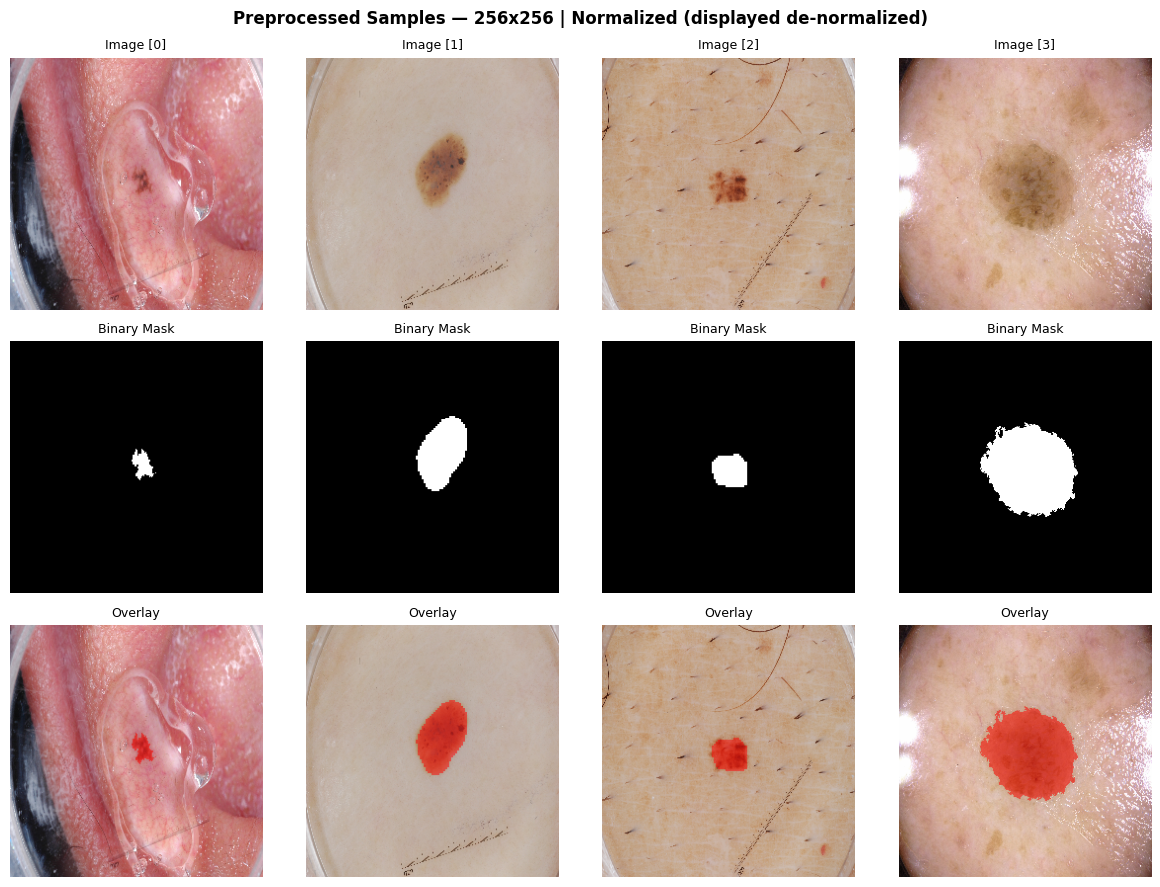

Saved → preprocessed_samples.png


In [ ]:
# De-normalize for display only
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    img = img * STD + MEAN
    return np.clip(img, 0, 1)

n   = 4
fig, axes = plt.subplots(3, n, figsize=(n * 3, 9))
fig.suptitle(
    f'Preprocessed Samples — {IMAGE_SIZE}x{IMAGE_SIZE} | Normalized (displayed de-normalized)',
    fontsize=12, fontweight='bold')

for i in range(n):
    img_disp  = denormalize(images[i])
    mask_disp = masks[i].squeeze().numpy()

    overlay         = img_disp.copy()
    lesion          = mask_disp > 0.5
    overlay[lesion] = (overlay[lesion] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5)

    axes[0, i].imshow(img_disp)
    axes[0, i].set_title(f'Image [{i}]', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(mask_disp, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Binary Mask', fontsize=9)
    axes[1, i].axis('off')

    axes[2, i].imshow(overlay)
    axes[2, i].set_title('Overlay', fontsize=9)
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig('../output/preprocessed_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved \u2192 preprocessed_samples.png')

---
## Step 12 — Export Split Info for the Training Guy

In [20]:
import json

split_info = {
    'images_path'   : IMAGES_PATH,
    'masks_path'    : MASKS_PATH,
    'image_size'    : IMAGE_SIZE,
    'batch_size'    : BATCH_SIZE,
    'random_seed'   : RANDOM_SEED,
    'total_samples' : len(full_dataset),
    'train_samples' : train_size,
    'val_samples'   : val_size,
    'train_indices' : train_idx,
    'val_indices'   : val_idx,
}

with open('../splits/dataset_split.json', 'w') as f:
    json.dump(split_info, f, indent=2)

print('✅ Saved \u2192 dataset_split.json')

✅ Saved → dataset_split.json


In [19]:
# ── Final handover summary ────────────────────────────────────────────────────
print('=' * 55)
print('   ISIC 2018 — DATASET HANDOVER SUMMARY')
print('=' * 55)
print(f'  Total samples      : {len(full_dataset)}')
print(f'  Train samples      : {train_size}')
print(f'  Val samples        : {val_size}')
print(f'  Image size         : {IMAGE_SIZE} x {IMAGE_SIZE}')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Train batches      : {len(train_loader)}')
print(f'  Val batches        : {len(val_loader)}')
print(f'  Image tensor       : (B, 3, {IMAGE_SIZE}, {IMAGE_SIZE})  float32')
print(f'  Mask tensor        : (B, 1, {IMAGE_SIZE}, {IMAGE_SIZE})  float32')
print(f'  Mask values        : 0.0 = background  |  1.0 = lesion')
print(f'  Normalization      : ImageNet mean/std')
print(f'  Augmentation       : NONE (baseline — add later if needed)')
print('=' * 55)
print()
print('  UNet++ config to use:')
print('    in_channels  = 3')
print('    out_channels = 1')
print('    depth        = 4')
print('    base_filters = 32  (or 64 for better accuracy)')
print()
print('  Recommended training settings:')
print('    Loss      : nn.BCEWithLogitsLoss()')
print('    Optimizer : Adam(lr=1e-4)')
print('    Metrics   : Dice Score + IoU (Jaccard)')
print('    Epochs    : 50  (watch val loss for early stopping)')
print('=' * 55)
print()
print('  Files generated by this notebook:')
print('    raw_samples.png          \u2190 raw image/mask/overlay visualization')
print('    mask_distribution.png    \u2190 class balance analysis')
print('    preprocessed_samples.png \u2190 final tensor visualization')
print('    dataset_split.json       \u2190 train/val indices for training notebook')

   ISIC 2018 — DATASET HANDOVER SUMMARY
  Total samples      : 2594
  Train samples      : 2076
  Val samples        : 518
  Image size         : 256 x 256
  Batch size         : 8
  Train batches      : 260
  Val batches        : 65
  Image tensor       : (B, 3, 256, 256)  float32
  Mask tensor        : (B, 1, 256, 256)  float32
  Mask values        : 0.0 = background  |  1.0 = lesion
  Normalization      : ImageNet mean/std
  Augmentation       : NONE (baseline — add later if needed)

  UNet++ config to use:
    in_channels  = 3
    out_channels = 1
    depth        = 4
    base_filters = 32  (or 64 for better accuracy)

  Recommended training settings:
    Loss      : nn.BCEWithLogitsLoss()
    Optimizer : Adam(lr=1e-4)
    Metrics   : Dice Score + IoU (Jaccard)
    Epochs    : 50  (watch val loss for early stopping)

  Files generated by this notebook:
    raw_samples.png          ← raw image/mask/overlay visualization
    mask_distribution.png    ← class balance analysis
    prepr